--------------------------------------------------
🎯 BASELINE MAE: 6.41 children
This means the simple 'naive' guess is off by an average of 6 children per day.
--------------------------------------------------


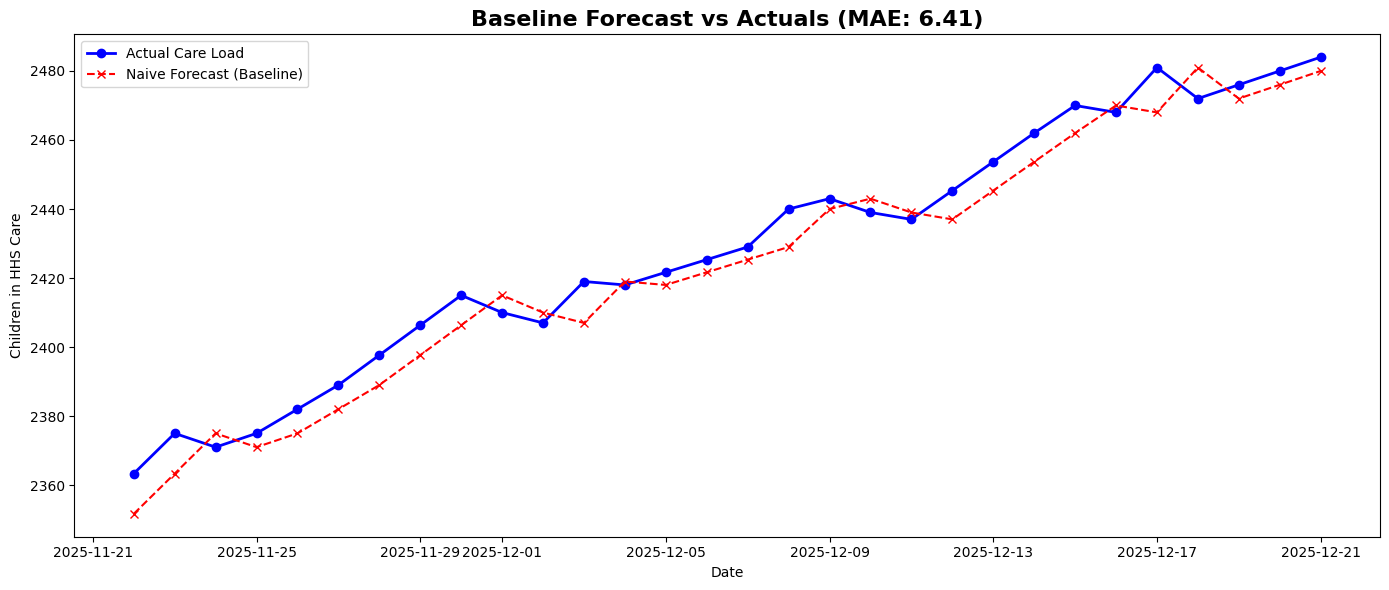

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# ==========================================
# 0. THE FIX: LOAD & CLEAN DATA INSTANTLY
# ==========================================
try:
    df = pd.read_csv('data/HHS_Unaccompanied_Alien_Children_Program.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/HHS_Unaccompanied_Alien_Children_Program.csv')

df.columns = df.columns.str.strip()
df['Children in HHS Care'] = df['Children in HHS Care'].replace({',': ''}, regex=True)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date'])
df = df.set_index('Date')
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_clean = df.reindex(full_date_range).interpolate(method='linear')

# ==========================================
# 1. FEATURE ENGINEERING 
# ==========================================
df_features = df_clean.copy()
df_features['Care_Load_Lag1'] = df_features['Children in HHS Care'].shift(1)
df_features['Care_Load_Roll7'] = df_features['Children in HHS Care'].rolling(window=7).mean()
df_features['Net_Pressure'] = df_features['Children transferred out of CBP custody'] - df_features['Children discharged from HHS Care']
df_features = df_features.dropna()

# ==========================================
# 2. TRAIN-TEST SPLIT
# ==========================================
test_days = 30
train = df_features.iloc[:-test_days].copy()
test = df_features.iloc[-test_days:].copy()

# ==========================================
# 3. BASELINE EVALUATION
# ==========================================
test['Naive_Forecast'] = test['Care_Load_Lag1']
mae = mean_absolute_error(test['Children in HHS Care'], test['Naive_Forecast'])

print("--------------------------------------------------")
print(f"🎯 BASELINE MAE: {mae:.2f} children")
print(f"This means the simple 'naive' guess is off by an average of {round(mae)} children per day.")
print("--------------------------------------------------")

# ==========================================
# 4. VISUALIZE THE BASELINE
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(test.index, test['Children in HHS Care'], label='Actual Care Load', color='blue', linewidth=2, marker='o')
plt.plot(test.index, test['Naive_Forecast'], label='Naive Forecast (Baseline)', color='red', linestyle='--', marker='x')

plt.title(f'Baseline Forecast vs Actuals (MAE: {mae:.2f})', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Children in HHS Care')
plt.legend()
plt.tight_layout()
plt.show()

Training XGBoost Model...
--------------------------------------------------
🎯 BASELINE MAE: 6.41 children
🚀 XGBOOST MAE:  8.60 children
--------------------------------------------------
⚠️ XGBoost did not beat the baseline. We may need to tune it.


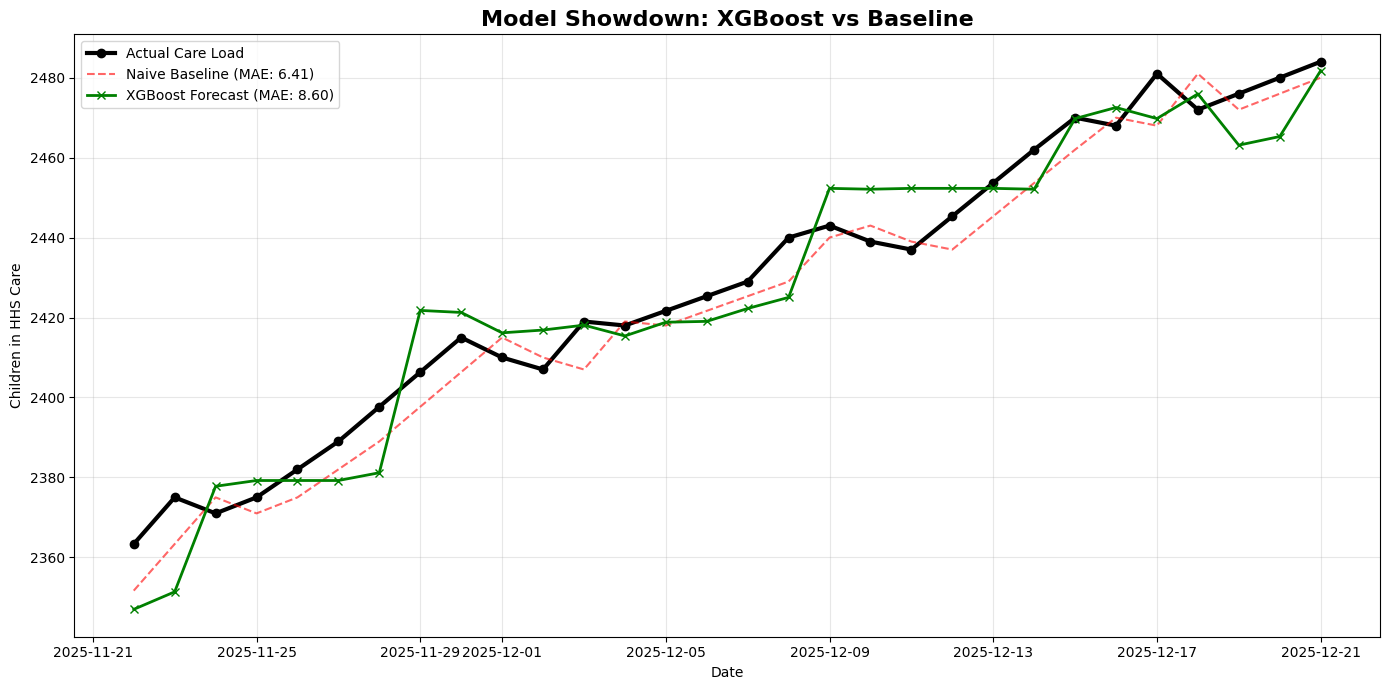

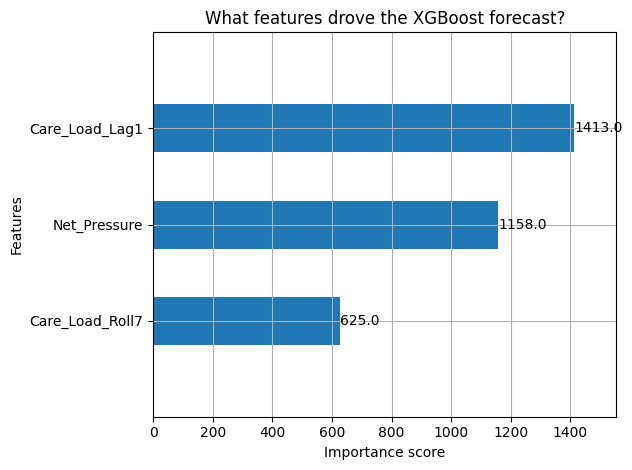

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore') # Hides annoying pandas warnings

# ==========================================
# 1. LOAD & CLEAN DATA (The Unbreakable Pipeline)
# ==========================================
try:
    df = pd.read_csv('data/HHS_Unaccompanied_Alien_Children_Program.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/HHS_Unaccompanied_Alien_Children_Program.csv')

df.columns = df.columns.str.strip()
df['Children in HHS Care'] = df['Children in HHS Care'].replace({',': ''}, regex=True)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date'])
df = df.set_index('Date')
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_clean = df.reindex(full_date_range).interpolate(method='linear')

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df_features = df_clean.copy()
df_features['Care_Load_Lag1'] = df_features['Children in HHS Care'].shift(1)
df_features['Care_Load_Roll7'] = df_features['Children in HHS Care'].rolling(window=7).mean()
df_features['Net_Pressure'] = df_features['Children transferred out of CBP custody'] - df_features['Children discharged from HHS Care']
df_features = df_features.dropna()

# ==========================================
# 3. SET UP XGBOOST (Train / Test Split)
# ==========================================
feature_columns = ['Care_Load_Lag1', 'Care_Load_Roll7', 'Net_Pressure']
target_column = 'Children in HHS Care'

X = df_features[feature_columns]
y = df_features[target_column]

test_days = 30
X_train, X_test = X.iloc[:-test_days], X.iloc[-test_days:]
y_train, y_test = y.iloc[:-test_days], y.iloc[-test_days:]

# Calculate Baseline (for comparison)
naive_forecast = X_test['Care_Load_Lag1']
baseline_mae = mean_absolute_error(y_test, naive_forecast)

# ==========================================
# 4. TRAIN & EVALUATE XGBOOST
# ==========================================
print("Training XGBoost Model...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make Predictions
xgb_predictions = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print("--------------------------------------------------")
print(f"🎯 BASELINE MAE: {baseline_mae:.2f} children")
print(f"🚀 XGBOOST MAE:  {xgb_mae:.2f} children")
print("--------------------------------------------------")
if xgb_mae < baseline_mae:
    print("✅ SUCCESS: Your Machine Learning model beat the baseline guess!")
else:
    print("⚠️ XGBoost did not beat the baseline. We may need to tune it.")

# ==========================================
# 5. VISUALIZE THE SHOWDOWN
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Care Load', color='black', linewidth=3, marker='o')
plt.plot(y_test.index, naive_forecast, label=f'Naive Baseline (MAE: {baseline_mae:.2f})', color='red', linestyle='--', alpha=0.6)
plt.plot(y_test.index, xgb_predictions, label=f'XGBoost Forecast (MAE: {xgb_mae:.2f})', color='green', linewidth=2, marker='x')

plt.title('Model Showdown: XGBoost vs Baseline', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Children in HHS Care')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 6. FEATURE IMPORTANCE
# ==========================================
xgb.plot_importance(xgb_model, importance_type='weight', title='What features drove the XGBoost forecast?', height=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore") # Hides statistical convergence warnings

# ==========================================
# 0. LOAD & CLEAN DATA INSTANTLY
# ==========================================
try:
    df = pd.read_csv('data/HHS_Unaccompanied_Alien_Children_Program.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/HHS_Unaccompanied_Alien_Children_Program.csv')

df.columns = df.columns.str.strip()
df['Children in HHS Care'] = df['Children in HHS Care'].replace({',': ''}, regex=True)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date'])
df = df.set_index('Date')
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_clean = df.reindex(full_date_range).interpolate(method='linear')

# ==========================================
# 1. PREPARE DATA FOR SARIMA
# ==========================================
target = df_clean['Children in HHS Care']

# Train-Test Split (Strictly the last 30 days)
test_days = 30
train_sarima = target.iloc[:-test_days]
test_sarima = target.iloc[-test_days:]

# ==========================================
# 2. TRAIN & EVALUATE SARIMA
# ==========================================
print("Training SARIMA Model... (This might take 15-30 seconds)")
# order=(1,1,1): Looks at 1 day of lag, smooths the trend, looks at 1 day of errors
# seasonal_order=(1,1,1,7): Looks for patterns repeating every 7 days
sarima_model = SARIMAX(train_sarima, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_result = sarima_model.fit(disp=False)

# Forecast the next 30 days
sarima_forecast = sarima_result.predict(start=len(train_sarima), end=len(train_sarima)+test_days-1)
sarima_forecast.index = test_sarima.index

# Evaluate
sarima_mae = mean_absolute_error(test_sarima, sarima_forecast)

print("--------------------------------------------------")
print(f"📊 SARIMA MAE: {sarima_mae:.2f} children")
print("--------------------------------------------------")

# ==========================================
# 3. VISUALIZE
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(test_sarima.index, test_sarima, label='Actual Care Load', color='black', linewidth=3, marker='o')
plt.plot(test_sarima.index, sarima_forecast, label=f'SARIMA Forecast (MAE: {sarima_mae:.2f})', color='purple', linewidth=2, marker='s')

plt.title(f'Statistical Model: SARIMA Evaluation', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Children in HHS Care')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training SARIMA Model... (This might take 15-30 seconds)
--------------------------------------------------
📊 SARIMA MAE: 28.22 children
--------------------------------------------------
